# Plot from parquet

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

checkpoint_path = "./data_vm/llm_agreement_scores_qwen3_vllm_with_stage2.parquet"
answers_path = "../../data/r2_cleaned.csv"

df_comp = pd.read_parquet(checkpoint_path)

df_answers = pd.read_csv(answers_path, keep_default_na=False) #keep_default_na=False to avoid converting empty strings to NaN
df_answers = df_answers[df_answers["REPETITION"] == 1].reset_index(drop=True)
# drop block 2
df_answers = df_answers[df_answers["BLOCK"] != 2].reset_index(drop=True)
df_answers["VIDEO_SECTOR"] = df_answers["VIDEO"].apply(lambda x: "LIMA" if int(x.split("_")[1]) <= 100 else "NYC")

df_comp.head()

,VIDEO,QUESTION_NUM,VIDEO_SECTOR,BLOCK,AGENT_I,ANSWER_I,AGENT_J,ANSWER_J,SCORE,EVALUATION,REASONING_CONTENT,RAW_OUTPUT,STAGE2_SCORE,STAGE2_EVALUATION,STAGE2_REASONING_CONTENT,STAGE2_RAW_OUTPUT
0,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_1,The ego vehicle is accelerating slowly because...,1.0,Both responses provide the same factual answer...,"Okay, let's tackle this. The question is askin...","{\n ""Evaluation"": ""Both responses provide the...",2.0,Both responses identify the same core conclusi...,"Okay, let's tackle this evaluation. The questi...","{\n ""Evaluation"": ""Both responses identify th..."
1,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_2,The ego vehicle is turning to the right,1.0,Both responses describe the ego vehicle's acti...,"Okay, let's see. The question is asking about ...","{\n ""Evaluation"": ""Both responses describe th...",-2.0,The responses contradict each other: 'accelera...,"Okay, let's tackle this evaluation. The questi...","{\n ""Evaluation"": ""The responses contradict e..."
2,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_3,the ego vehicle brakes and steers slightly to ...,1.0,Both responses describe the ego vehicle's acti...,"Okay, let's see. The question is asking about ...","{\n ""Evaluation"": ""Both responses describe th...",-2.0,Response A states the ego vehicle is accelerat...,"Okay, let's tackle this evaluation. The questi...","{\n ""Evaluation"": ""Response A states the ego ..."
3,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_4,Braking to yield,1.0,Both responses describe the ego vehicle's acti...,"Okay, let's see. The question is asking about ...","{\n ""Evaluation"": ""Both responses describe th...",-2.0,Responses contradict on the core action (accel...,"Okay, let's tackle this evaluation. The questi...","{\n ""Evaluation"": ""Responses contradict on th..."
4,Robusto2_153,1,NYC,1,human_lima_1,The ego vehicle is accelerating slowly because...,human_lima_5,The ego vehicle is moving forward while mainta...,1.0,Both responses describe the ego vehicle's moti...,"Okay, let's tackle this. The question is askin...","{\n ""Evaluation"": ""Both responses describe th...",2.0,Both responses agree that the ego vehicle is i...,"Okay, let's tackle this evaluation. The questi...","{\n ""Evaluation"": ""Both responses agree that ..."


In [2]:
#Now plot the df_comp
agg_df = (
    df_comp
    .groupby(
        ["VIDEO", "QUESTION_NUM","BLOCK","VIDEO_SECTOR", "AGENT_I", "AGENT_J"],
        as_index=False
    )["STAGE2_SCORE"]
    .mean()
)

agg_df2 = (
    agg_df
    .groupby(
        ["AGENT_I", "AGENT_J", "BLOCK","VIDEO_SECTOR"],
        as_index=False
    )["STAGE2_SCORE"]
    .mean()
)   
agg_df2

,AGENT_I,AGENT_J,BLOCK,VIDEO_SECTOR,STAGE2_SCORE
0,Cosmos-Reason2-8B,Cosmos-Reason2-8B,1,LIMA,2.00
1,Cosmos-Reason2-8B,Cosmos-Reason2-8B,1,NYC,2.00
2,Cosmos-Reason2-8B,Cosmos-Reason2-8B,3,LIMA,2.00
3,Cosmos-Reason2-8B,Cosmos-Reason2-8B,3,NYC,2.00
4,Cosmos-Reason2-8B,Cosmos-Reason2-8B,4,LIMA,1.92
...,...,...,...,...,...
4369,human_nyc_17,human_nyc_17,1,NYC,2.00
4370,human_nyc_17,human_nyc_17,3,LIMA,2.00
4371,human_nyc_17,human_nyc_17,3,NYC,2.00
4372,human_nyc_17,human_nyc_17,4,LIMA,2.00


In [3]:
def plot_judge(rsa_df, agents, title):
    nrows = 2
    ncols = 3
    fig, ax = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows),sharex=True,sharey=True)
    c = sns.diverging_palette(220, 20, as_cmap=True)

    for id_r, region in enumerate(df_answers["VIDEO_SECTOR"].unique()[::-1]):
        blocks = df_answers["BLOCK"].astype(int).unique()
        blocks = blocks[blocks != 2]
        print(f"Plotting region: {region} with blocks: {blocks}")
        for block in blocks:
            x_index = block - 1 if block < 2 else block - 2
            c_ax = ax[id_r, x_index]

            #select the data for the region and block
            df_block = rsa_df[(rsa_df["VIDEO_SECTOR"] == region) & (rsa_df["BLOCK"] == block)]
            rsa_matrix = df_block.pivot(index="AGENT_I", columns="AGENT_J", values="STAGE2_SCORE")
            
            #order columns and rows by agents order
            rsa_matrix = rsa_matrix.reindex(index=agents, columns=agents)
            sns.heatmap(rsa_matrix.to_numpy(), annot=False, xticklabels=rsa_matrix.columns, yticklabels=rsa_matrix.columns, cmap=c, ax=c_ax,square=True, vmin=-2, vmax=2,annot_kws={"fontsize":7})
            c_ax.set_title(f"Region: {region}, Block: {block}", fontsize=16, weight="bold")
            
    fig.suptitle(title, fontsize=24, weight="bold")
    out_name = title.replace(" ", "_").replace(":","-").lower()
    fig.tight_layout()
    fig.subplots_adjust(top=0.92)
    fig.savefig(f"./judge_output_{out_name}.png", dpi=300)
    fig.savefig(f"./judge_output_{out_name}.svg", dpi=300)

Plotting region: LIMA with blocks: [1 3 4]
Plotting region: NYC with blocks: [1 3 4]


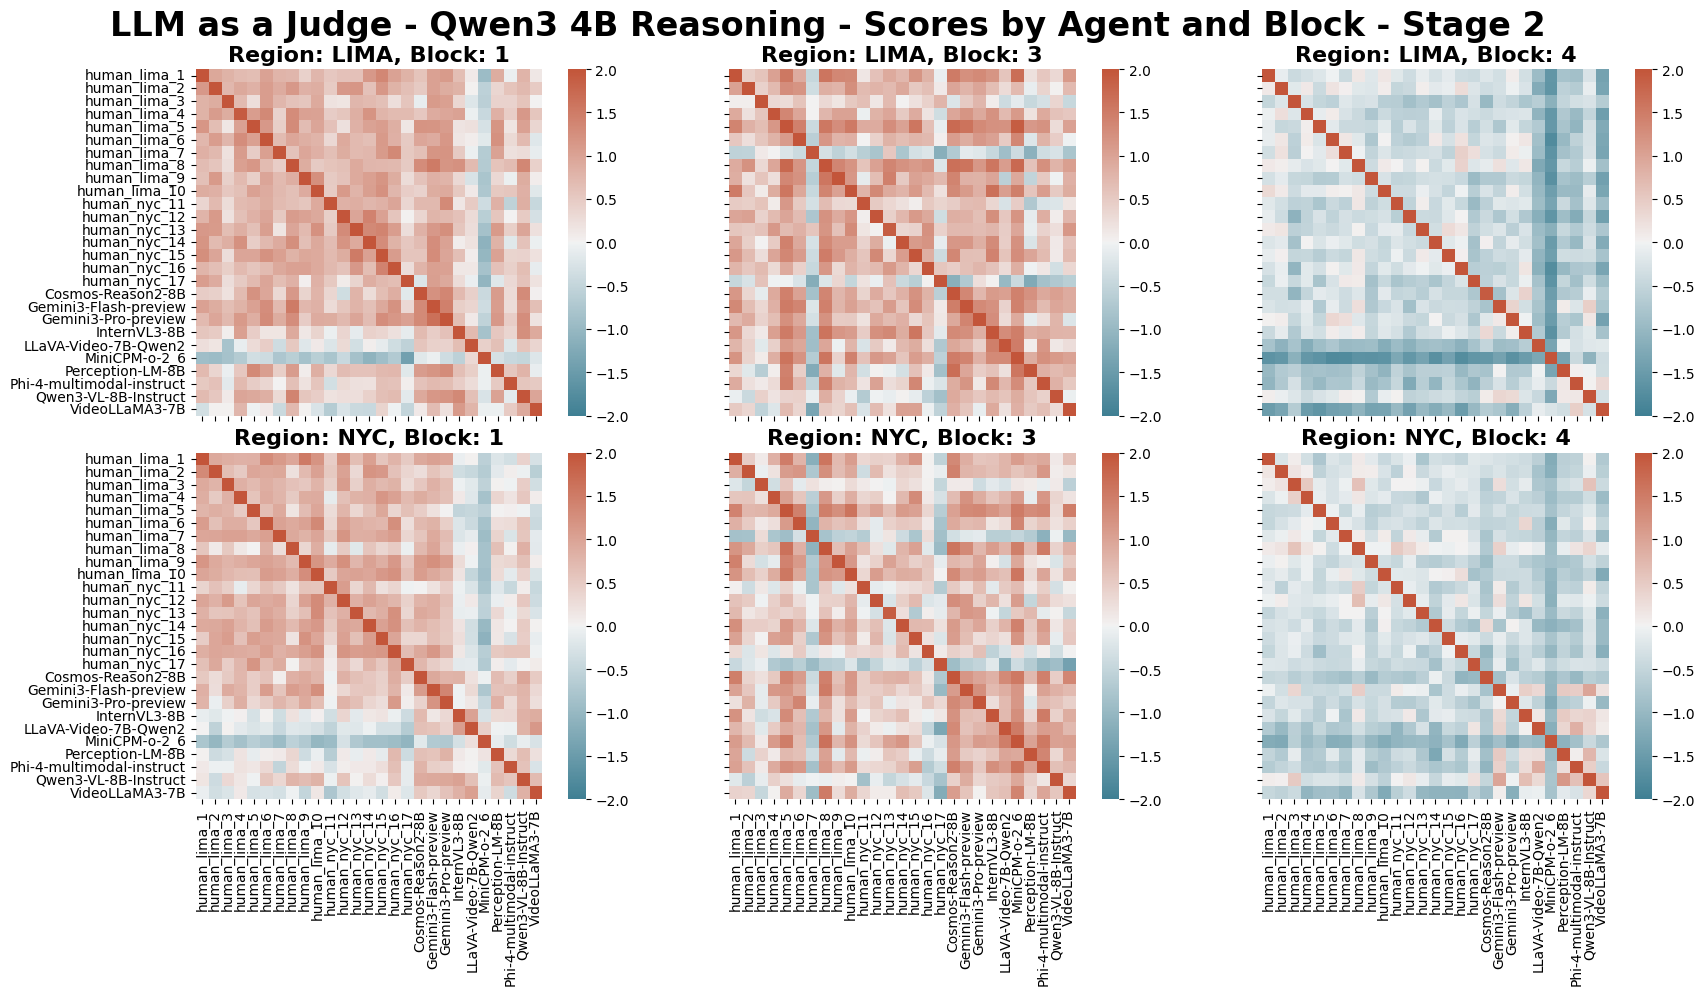

In [4]:
plot_judge(agg_df2, agents=df_answers["AGENT"].unique(), title="LLM as a Judge - Qwen3 4B Reasoning - Scores by Agent and Block - Stage 2")

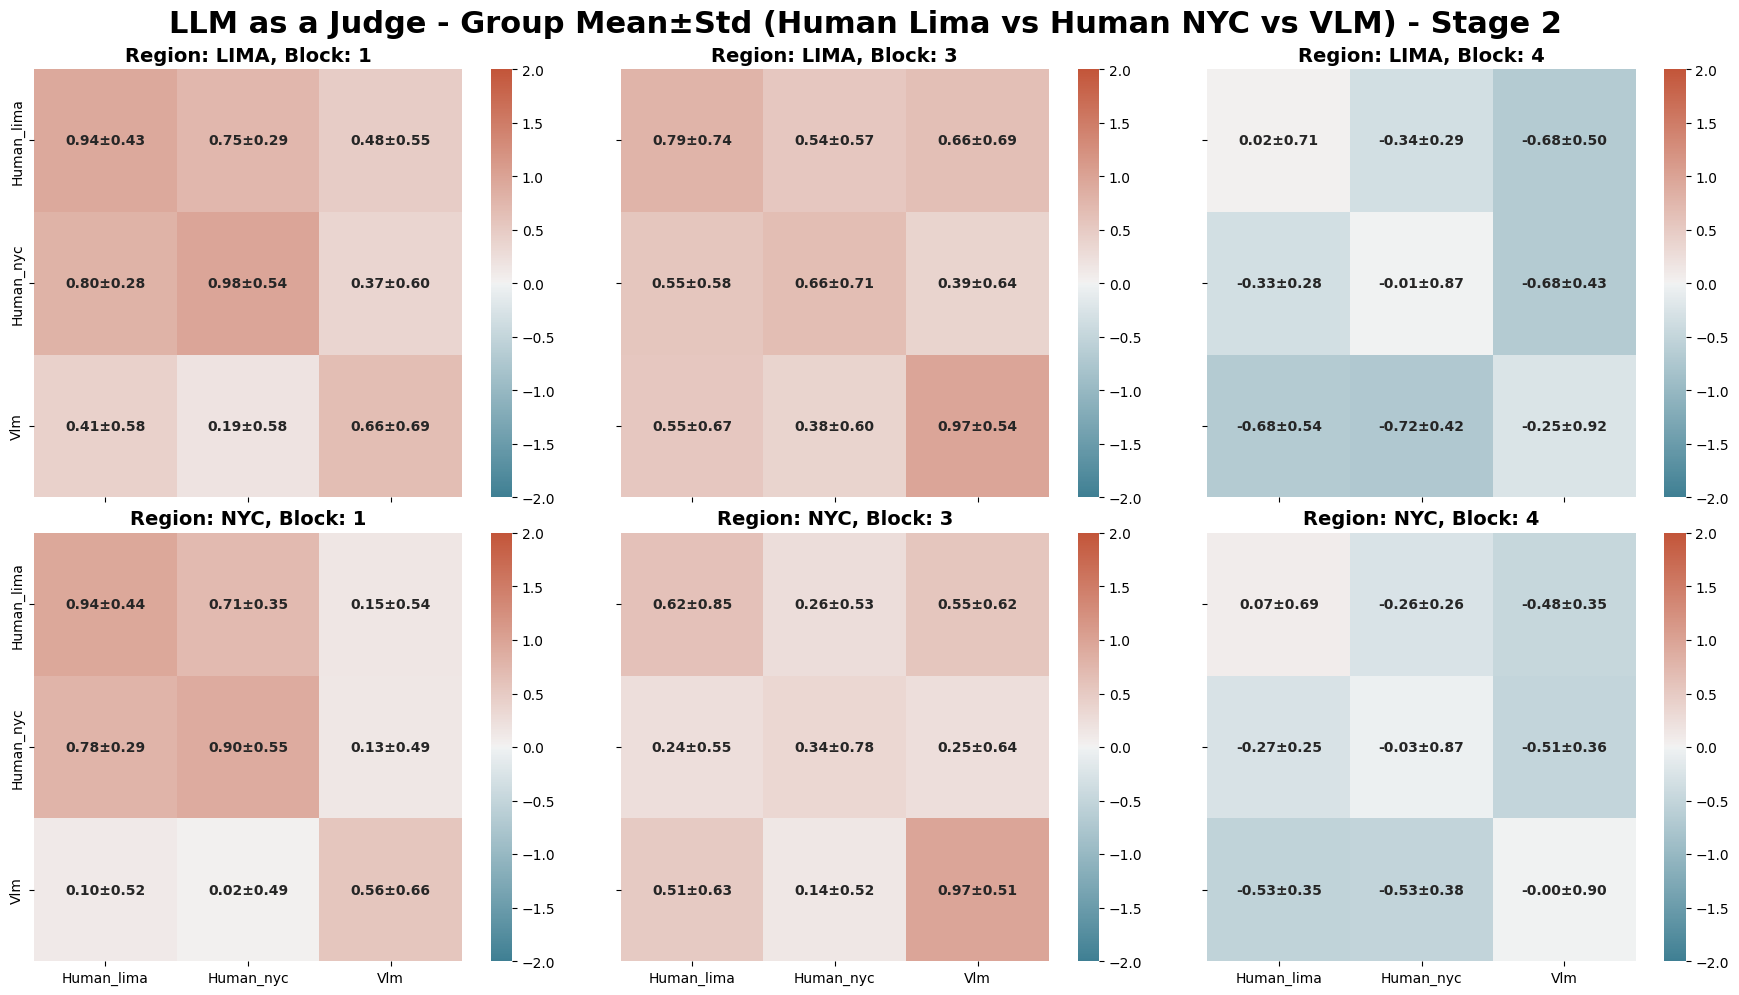

In [5]:
c = sns.diverging_palette(220, 20, as_cmap=True)

def categorize_agent(agent_name):
    agent_name = str(agent_name).lower()
    if "lima" in agent_name:
        return "Human_lima"
    elif "nyc" in agent_name or "new york" in agent_name:
        return "Human_nyc"
    else:
        return "Vlm"

def build_group_stat_dict(df_scores):
    df = df_scores.copy()
    df["GROUP_I"] = df["AGENT_I"].apply(categorize_agent)
    df["GROUP_J"] = df["AGENT_J"].apply(categorize_agent)

    group_order = ["Human_lima", "Human_nyc", "Vlm"]
    result = {}

    for sector in sorted(df["VIDEO_SECTOR"].unique()):
        for block in sorted(df["BLOCK"].astype(int).unique()):
            df_filtered = df[(df["VIDEO_SECTOR"] == sector) & (df["BLOCK"].astype(int) == int(block))].copy()

            mean_mtx = df_filtered.pivot_table(
                index="GROUP_I", columns="GROUP_J", values="STAGE2_SCORE", aggfunc="mean"
            ).reindex(index=group_order, columns=group_order)

            std_mtx = df_filtered.pivot_table(
                index="GROUP_I", columns="GROUP_J", values="STAGE2_SCORE", aggfunc="std"
            ).reindex(index=group_order, columns=group_order)

            result[(sector, int(block))] = (mean_mtx, std_mtx)

    return result

def plot_group_mean_std_heatmaps(stat_dict, title):
    # sectors = sorted(df_answers["VIDEO_SECTOR"].unique())[::-1]
    sectors = df_answers["VIDEO_SECTOR"].unique()[::-1]
    blocks = sorted(df_answers["BLOCK"].astype(int).unique())
    nrows, ncols = len(sectors), len(blocks)

    fig, ax = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), sharex=True, sharey=True)
    if nrows == 1 and ncols == 1:
        ax = np.array([[ax]])
    elif nrows == 1:
        ax = np.array([ax])
    elif ncols == 1:
        ax = np.array([[a] for a in ax])

    for i, sector in enumerate(sectors):
        for j, block in enumerate(blocks):
            c_ax = ax[i, j]
            mean_mtx, std_mtx = stat_dict[(sector, int(block))]

            annot_text = []
            for r in range(len(mean_mtx.index)):
                row = []
                for col_idx in range(len(mean_mtx.columns)):
                    m = mean_mtx.iloc[r, col_idx]
                    s = std_mtx.iloc[r, col_idx]
                    if pd.isna(m):
                        row.append("-")
                    elif pd.isna(s):
                        row.append(f"{m:.2f}±0.00")
                    else:
                        row.append(f"{m:.2f}±{s:.2f}")
                annot_text.append(row)

            sns.heatmap(
                mean_mtx.to_numpy(),
                annot=annot_text,
                fmt="",
                cmap=c,
                center=0,
                vmin=-2,
                vmax=2,
                square=True,
                xticklabels=mean_mtx.columns,
                yticklabels=mean_mtx.index,
                annot_kws={"fontsize": 10, "weight": "bold"},
                ax=c_ax,
            )
            c_ax.set_title(f"Region: {sector}, Block: {block}", fontsize=14, weight="bold")

    fig.suptitle(title, fontsize=22, weight="bold")
    fig.tight_layout()
    out_name = title.replace(" ", "_").replace(":", "-").lower()
    fig.subplots_adjust(top=0.92)
    fig.savefig(f"./judge_group_stats_{out_name}.png", dpi=300)
    fig.savefig(f"./judge_group_stats_{out_name}.svg", dpi=300)

# Build and plot 3x3 group-level mean±std matrices
group_stats = build_group_stat_dict(agg_df2)
plot_group_mean_std_heatmaps(
    group_stats,
    title="LLM as a Judge - Group Mean±Std (Human Lima vs Human NYC vs VLM) - Stage 2",
)

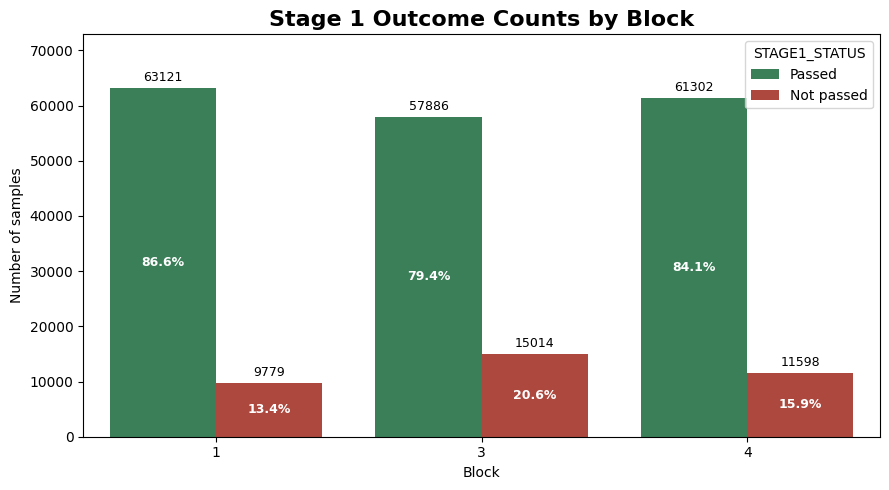

STAGE1_STATUS,Not passed,Passed
BLOCK,,
1,9779,63121
3,15014,57886
4,11598,61302


In [5]:
# Stage 1 pass status by block: missing STAGE2_SCORE means the sample did not pass Stage 1
stage1_status = df_comp.copy()
stage1_status["STAGE1_STATUS"] = np.where(
    stage1_status["STAGE2_SCORE"].isna(),
    "Not passed",
    "Passed",
)

status_by_block = (
    stage1_status
    .groupby(["BLOCK", "STAGE1_STATUS"], as_index=False)
    .size()
    .rename(columns={"size": "COUNT"})
)

# Ensure consistent order and include missing combinations as zero
block_order = sorted(stage1_status["BLOCK"].dropna().astype(int).unique())
status_order = ["Passed", "Not passed"]
full_index = pd.MultiIndex.from_product(
    [block_order, status_order],
    names=["BLOCK", "STAGE1_STATUS"],
)

status_by_block = (
    status_by_block
    .assign(BLOCK=lambda d: d["BLOCK"].astype(int))
    .set_index(["BLOCK", "STAGE1_STATUS"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

block_totals = status_by_block.groupby("BLOCK")["COUNT"].sum().sort_index()
y_max = int(block_totals.iloc[0])

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=status_by_block,
    x="BLOCK",
    y="COUNT",
    hue="STAGE1_STATUS",
    hue_order=status_order,
    palette={"Passed": "#2E8B57", "Not passed": "#C0392B"},
)
ax.set_title("Stage 1 Outcome Counts by Block", fontsize=16, weight="bold")
ax.set_xlabel("Block")
ax.set_ylabel("Number of samples")
ax.set_ylim(0, y_max)

# Add absolute count on top and percentage (within each block) inside each bar
for container in ax.containers:
    for i, p in enumerate(container):
        h = int(p.get_height())
        block = block_order[i]
        pct = (h / block_totals.loc[block]) * 100 if block_totals.loc[block] > 0 else 0

        if h > 0:
            ax.annotate(
                f"{h}",
                (p.get_x() + p.get_width() / 2.0, p.get_height()),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 3),
                textcoords="offset points",
            )
            ax.annotate(
                f"{pct:.1f}%",
                (p.get_x() + p.get_width() / 2.0, p.get_height() / 2.0),
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                weight="bold",
            )

plt.tight_layout()
plt.show()

status_by_block.pivot(index="BLOCK", columns="STAGE1_STATUS", values="COUNT").fillna(0).astype(int)